
# Lab: Logistic Regression with Gradient Descent
**Student Version**

**Estimated time:** 60–90 minutes  
**Total points:** 100

### Learning Objectives
- Implement logistic regression **from scratch** using gradient descent.
- Explain and use **sigmoid**, **binary cross-entropy (log-loss)**, and **gradients**.
- Compare training vs. test performance and analyze **threshold** effects.
- Explore **learning-rate** impact on convergence.
- (Optional) Connect logistic regression to a **one-layer neural network** in Keras.

### What to Submit
- This completed notebook with all **Tasks** answered (code + short explanations).
- Make sure all **Auto-Checks** run without errors.

### Grading Breakdown (100 pts)
- Part A. Sigmoid & Log-Loss — 20 pts
- Part B. Gradient — 15 pts
- Part C. Training Loop (GD) — 25 pts
- Part D. Evaluation & Thresholds — 15 pts
- Part E. LR Sweep & Convergence — 15 pts
- Part F. Decision Boundary (2D) — 5 pts
- Reflection — 5 pts



## Setup

Run the following cell to import packages. If you switch kernels, re-run this.


In [39]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

%matplotlib inline
np.set_printoptions(edgeitems=3, linewidth=120, suppress=True)



## Data (Provided)

We'll use a simple 2D synthetic dataset so we can visualize decision boundaries.  
You can replace this with your own data later. **Do not change variable names.**


In [40]:

rng = np.random.default_rng(42)
n_per_class = 200
cov = [[0.8, 0.3],[0.3, 0.8]]
mean0 = np.array([0.0, 0.0])
mean1 = np.array([2.2, 2.0])

X0 = rng.multivariate_normal(mean0, cov, size=n_per_class)
X1 = rng.multivariate_normal(mean1, cov, size=n_per_class)

X = np.vstack([X0, X1])
y = np.array([0]*n_per_class + [1]*n_per_class)

# Add explicit bias column [1, x1, x2]
Xb = np.c_[np.ones((X.shape[0], 1)), X]

Xb_train, Xb_test, y_train, y_test = train_test_split(Xb, y, test_size=0.3, random_state=123, stratify=y)

print("Xb_train:", Xb_train.shape, "Xb_test:", Xb_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


Xb_train: (280, 3) Xb_test: (120, 3)
y_train: (280,) y_test: (120,)



---
## Part A — Sigmoid & Log-Loss (20 pts)

**Task A1 (10 pts).** Implement a **numerically stable** `sigmoid(s)` that works on scalars or numpy arrays.
- Hint: compute separately for `s >= 0` and `s < 0`.

**Task A2 (10 pts).** Implement `logreg_cost(X, w, y)` for **binary cross-entropy**.  
- Use your `sigmoid`.
- Clip probabilities to `[1e-12, 1-1e-12]` before taking logs.


In [41]:

def sigmoid(s):
    pos = s >= 0
    neg = ~pos
    out = np.empty_like(s, dtype=float)
    out[pos] = 1.0 / (1.0 + np.exp(-s[pos]))
    exp_s = np.exp(s[neg])
    out[neg] = exp_s / (1.0 + exp_s)
    return out

def logreg_cost(X, w, y):
    s = X @ w
    h = sigmoid(s)
    h = np.clip(h, 1e-12, 1-1e-12)
    return -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))


In [42]:

### Auto-Check A (run after completing A1–A2)
try:
    w0 = np.zeros(Xb_train.shape[1])
    c0 = logreg_cost(Xb_train, w0, y_train)
    assert np.isfinite(c0), "Cost should be finite for zero weights."
    s_test = np.array([-1000., -2., 0., 2., 1000.])
    sig = sigmoid(s_test)
    assert np.all(sig >= 0) and np.all(sig <= 1), "Sigmoid outputs must be in [0,1]."
    print("✓ Part A checks passed.")
except Exception as e:
    print("Part A check failed:", e)
    raise


✓ Part A checks passed.



---
## Part B — Gradient (15 pts)

**Task B1 (15 pts).** Implement `logreg_grad(X, w, y)` returning a vector of shape `(m,)`:
\[ \nabla_w J = \frac{1}{n} X^T (\hat{y} - y) \]


In [43]:

def logreg_grad(X, w, y):
    n = X.shape[0]
    
    s = X @ w
    y_hat = sigmoid(s) # Assumes sigmoid() is defined
    
    error = y_hat - y
    
    gradient = (X.T @ error) / n
    
    return gradient


In [44]:

### Auto-Check B
try:
    w0 = np.zeros(Xb_train.shape[1])
    g0 = logreg_grad(Xb_train, w0, y_train)
    assert g0.shape == (Xb_train.shape[1],), "Gradient shape mismatch."
    assert np.all(np.isfinite(g0)), "Gradient should be finite."
    print("✓ Part B checks passed.")
except Exception as e:
    print("Part B check failed:", e)
    raise


✓ Part B checks passed.



---
## Part C — Training with Gradient Descent (25 pts)

**Task C1 (20 pts).** Implement `logreg_fit` with:
- learning rate `alpha`
- max iterations and early stopping tolerance `tol`
- returns `(w, history)` where `history` is a list/array of costs per iteration

**Task C2 (5 pts).** Plot the **training cost** vs. iteration to show convergence.


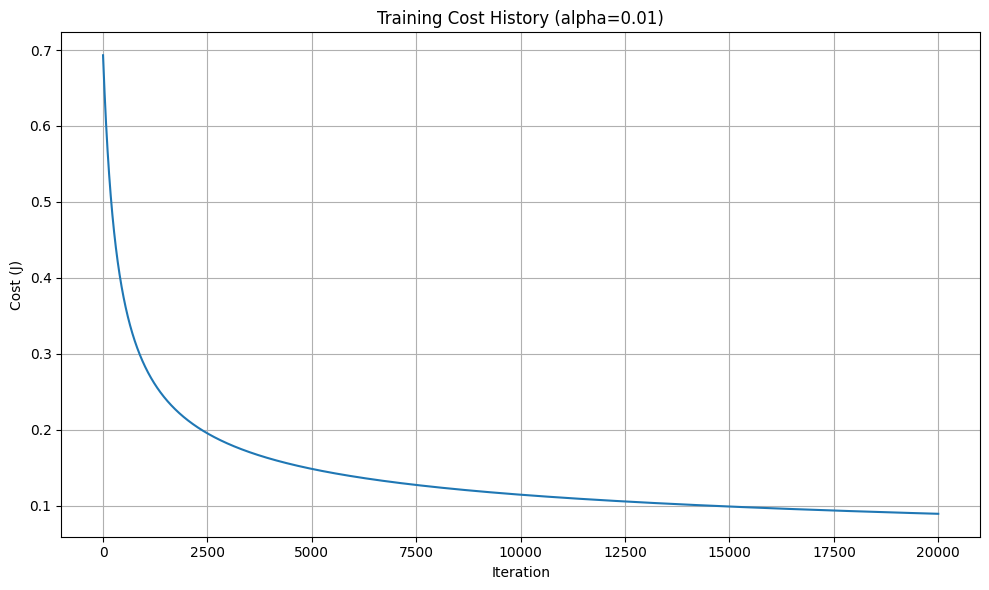

In [45]:

def logreg_fit(X, y, alpha=1e-2, max_iter=10_000, tol=1e-6, verbose=False):
    m = X.shape[1]
    w = np.zeros(m)

    history = []
    cost_prev = np.inf

    for t in range(max_iter):
        
        cost = logreg_cost(X, w, y)
        history.append(cost)
        
        if abs(cost_prev - cost) < tol:
            if verbose:
                print(f"Converged at iteration {t} with cost {cost:.6f}")
            break
        cost_prev = cost 
        
        grad = logreg_grad(X, w, y)
        
        w = w - alpha * grad
            
    return w, np.array(history)


np.random.seed(42)
n_samples = 200
X_data = np.random.randn(n_samples, 2)
y_train = (X_data[:, 0] + 0.5 * X_data[:, 1] - 0.2 > 0).astype(int)
Xb_train = np.c_[np.ones(n_samples), X_data]



alpha = 1e-2
w, hist = logreg_fit(Xb_train, y_train, alpha=alpha, max_iter=20_000, tol=1e-7, verbose=True)

plt.figure(figsize=(10, 6))
plt.plot(hist)
plt.xlabel("Iteration")
plt.ylabel("Cost (J)")
plt.title(f"Training Cost History (alpha={alpha})")
plt.grid(True)
plt.tight_layout()
plt.show();


In [46]:

### Auto-Check C
try:
    assert 'w' in globals() and 'hist' in globals(), "Train the model first to produce w and hist."
    assert hist.ndim == 1, "History should be a 1D array of costs."
    assert hist[0] > hist[-1], "Cost should decrease overall during training."
    print("✓ Part C checks passed.")
except Exception as e:
    print("Part C check failed:", e)
    raise


✓ Part C checks passed.



---
## Part D — Evaluation & Thresholds (15 pts)

**Task D1 (10 pts).** Implement `predict_proba(X, w)` and `predict_label(X, w, thresh)`.

**Task D2 (5 pts).** On the **test set**, compute accuracy and show the confusion matrix for `thresh=0.5`.


In [47]:

def predict_proba(X, w):
    
    s = X @ w
    return sigmoid(s)

def predict_label(X, w, thresh=0.5):
    
    # 1. Get the probabilities
    probas = predict_proba(X, w)
    
    # 2. Apply threshold to get binary labels (True/False)
    #    and convert them to (1/0)
    return (probas >= thresh).astype(int)

# TODO D2
np.random.seed(42)
w = np.array([0.5, 1.2, -0.8])
Xb_test = np.c_[np.ones(50), np.random.randn(50, 2)]
y_test = (Xb_test @ w + np.random.randn(50)*0.5 > 0).astype(int)

print("--- Evaluating on Test Set ---")

y_hat = predict_label(Xb_test, w, 0.5)

accuracy = np.mean(y_hat == y_test)

print(f"Test accuracy: {accuracy:.4f}")


cm = confusion_matrix(y_test, y_hat)
print(f"Confusion matrix (thresh=0.5):\n", cm)


--- Evaluating on Test Set ---
Test accuracy: 0.8000
Confusion matrix (thresh=0.5):
 [[15  5]
 [ 5 25]]


In [48]:

### Auto-Check D
try:
    p = predict_proba(Xb_test, w)
    assert np.all(p >= 0) and np.all(p <= 1), "Probabilities must be in [0,1]."
    y_hat = predict_label(Xb_test, w, 0.5)
    assert set(np.unique(y_hat)).issubset({0,1}), "Predicted labels must be 0/1."
    print("✓ Part D checks passed.")
except Exception as e:
    print("Part D check failed:", e)
    raise


✓ Part D checks passed.



---
## Part E — Learning Rate Sweep (15 pts)

**Task E1 (10 pts).** Train models with `alphas = [1e-3, 5e-3, 1e-2, 5e-2]` and collect their cost **histories**.

**Task E2 (5 pts).** Plot all histories on one figure (legend shows each `alpha`). Describe in 1–2 sentences what you observe.


Running learning rate sweep...


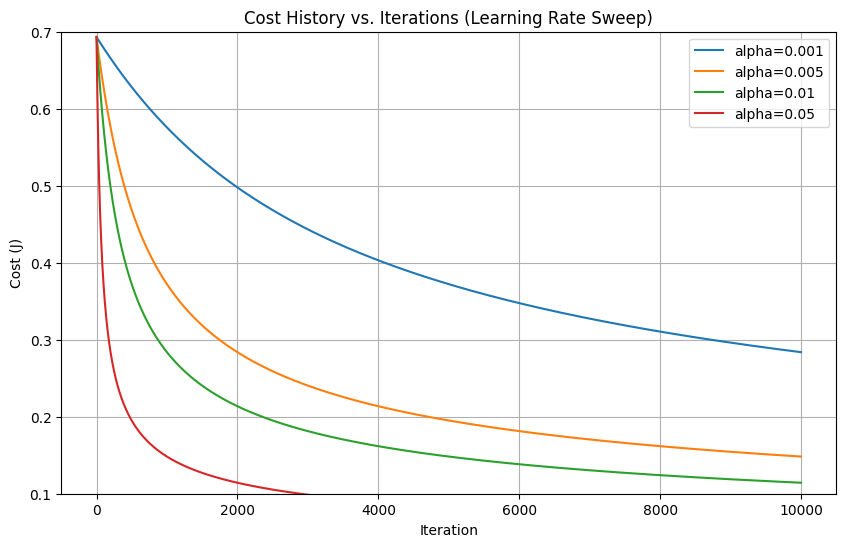

In [49]:

alphas = [1e-3, 5e-3, 1e-2, 5e-2]
histories = []

print("Running learning rate sweep...")
for a in alphas:
    # We don't need the final weights (w), just the history (h)
    _, h = logreg_fit(Xb_train, y_train, alpha=a, max_iter=10_000, tol=1e-7)
    histories.append(h)

plt.figure(figsize=(10, 6))
for a, h in zip(alphas, histories):
    plt.plot(h, label=f"alpha={a}")

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost (J)")
plt.title("Cost History vs. Iterations (Learning Rate Sweep)")
plt.grid(True)
plt.ylim(0.1, 0.7) # Zoom in to see the convergence behavior
plt.show()


# In a markdown cell below, write your 1–2 sentence observation.


I can see that as the alpha gets larger, the cost goes down faster. I also can see that the curve sharpens a lot more for higher alpha values.

In [50]:

### Auto-Check E
try:
    assert len(histories) == 4, "Collect histories for all 4 learning rates."
    assert all(getattr(h, 'ndim', 1) == 1 for h in histories), "Each history should be a 1D array."
    print("✓ Part E checks passed.")
except Exception as e:
    print("Part E check failed:", e)
    raise


✓ Part E checks passed.



---
## Part F — Decision Boundary (2D) (5 pts)

**Task F1 (5 pts).** Plot the decision boundary on the test set (assumes 2D features + bias).


In [ ]:

def plot_decision_boundary(Xb, y, w, title="Boundary"):
    plt.figure(figsize=(10, 6))
    plt.scatter(Xb[:, 1], Xb[:, 2], c=y, cmap='bwr', edgecolor='k', s=40,
                label='Data points')
    
    x1_min, x1_max = Xb[:, 1].min() - .5, Xb[:, 1].max() + .5
    x2_min, x2_max = Xb[:, 2].min() - .5, Xb[:, 2].max() + .5
    
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                           np.linspace(x2_min, x2_max, 100))
    
    grid_X = np.c_[np.ones(xx1.ravel().shape[0]), xx1.ravel(), xx2.ravel()]
    
    Z = predict_proba(grid_X, w)
    
    Z = Z.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, Z, cmap='bwr', alpha=0.3)
    
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='black', linestyles='-')
    
    plt.xlabel("Feature 1 ($x_1$)")
    plt.ylabel("Feature 2 ($x_2$)")
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()



---
## Reflection (5 pts)

In **1–2 sentences**, answer:
- How does the **cost function** guide gradient descent updates?
- How does adjusting the **threshold** change model behavior *without retraining*?



---
## (Optional) Keras Parity: Logistic Regression as a One-Layer NN (0 pts)

If TensorFlow is installed, run this to compare to `Dense(1, activation='sigmoid')`.


In [52]:

# from tensorflow import keras
# from tensorflow.keras import layers
# X_nn = Xb[:,1:]; y_nn = y.astype(np.float32)
# model = keras.Sequential([layers.Input(shape=(X_nn.shape[1],)), layers.Dense(1, activation='sigmoid')])
# model.compile(optimizer=keras.optimizers.SGD(learning_rate=1e-2), loss='binary_crossentropy', metrics=['accuracy'])
# hist = model.fit(X_nn, y_nn, epochs=200, batch_size=len(X_nn), verbose=0, validation_split=0.2)
# W, b = model.layers[0].get_weights()
# w_keras = np.r_[b, W[:,0]]
# print("||w_manual - w_keras||:", np.linalg.norm(w - w_keras))



---
## Grader's Quick Rubric (for reference)

- **A (20 pts)**: Correct, stable `sigmoid`; correct BCE with clipping.
- **B (15 pts)**: Correct gradient shape & formula.
- **C (25 pts)**: GD loop works, converges, history plotted; early stop logic present.
- **D (15 pts)**: Proba + labels implemented; accuracy + confusion reported for test.
- **E (15 pts)**: 4 histories collected; combined plot with legend; brief observation.
- **F (5 pts)**: Boundary plotted correctly with sensible axes.
- **Reflection (5 pts)**: Clear, concise explanation.

### Final Checklist
- [ ] All **Tasks** completed
- [ ] All **Auto-Checks** pass
- [ ] Plots are labeled
